In [41]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import json
from rdkit import Chem
import seaborn as sns

In [77]:
first_x_entries = []
with open('241114-gas-ir.json', 'r') as file:
    for i,line in enumerate(file):
        try:
            if i < 5:
                first_x_entries.append(json.loads(line))  # Assuming each line is a JSON object
            else:
                break 
        except json.JSONDecodeError:
              continue 

In [81]:
first_spec_dict = first_x_entries[0][0]
first_spec_dict.keys()

dict_keys(['id', 'uuid', 'mol_id', 'inchikey', 'smiles', 'recipe', 'data'])

In [89]:
first_spec_dict['data'].keys()

dict_keys(['intensity', 'wavenumber'])

In [82]:
first_spec_dict['smiles']

'COC(=O)CCc1cc(OC)c(C(C)(C)C)cc1-c1ccc[nH]c1=O'

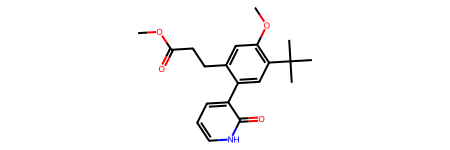

In [31]:
mol = Chem.MolFromSmiles(first_spec_dict['smiles'])
mol

In [36]:
print(first_spec_dict['data'].keys())
[len(first_spec_dict['data'][i]) for i in first_spec_dict['data'].keys()]

dict_keys(['intensity', 'wavenumber'])


[19999, 19999]

In [70]:
first_cm = np.array(first_spec_dict['data']['wavenumber'])
first_intensity = np.array(first_spec_dict['data']['intensity'])
segs = 20
ranges = np.linspace(first_cm.min(), first_cm.max(), segs, endpoint = True)
ranges

array([3.33580774e+00, 3.51436124e+03, 7.02538667e+03, 1.05364121e+04,
       1.40474375e+04, 1.75584630e+04, 2.10694884e+04, 2.45805138e+04,
       2.80915393e+04, 3.16025647e+04, 3.51135901e+04, 3.86246156e+04,
       4.21356410e+04, 4.56466664e+04, 4.91576919e+04, 5.26687173e+04,
       5.61797427e+04, 5.96907682e+04, 6.32017936e+04, 6.67128190e+04])

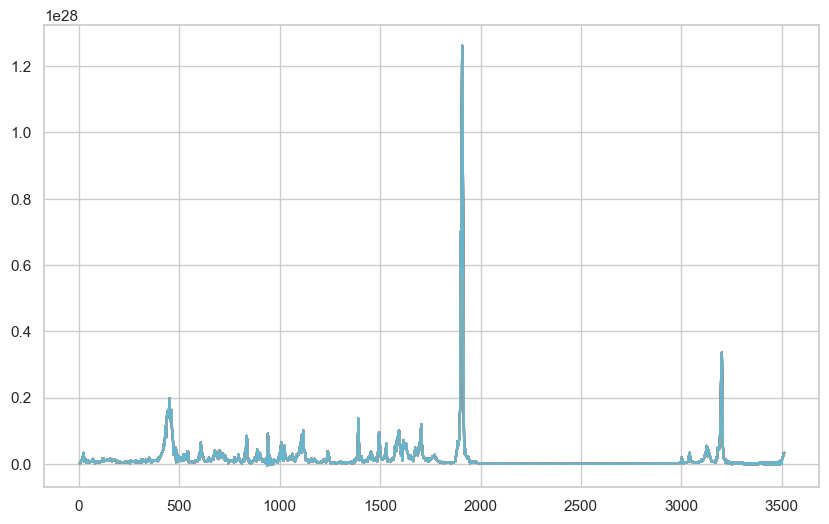

In [71]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
[
    sns.lineplot(x=first_cm[(first_cm >= ranges[0]) & (first_cm <= ranges[1])],
                 y=first_intensity[(first_cm >= ranges[0]) & (first_cm <= ranges[1])])
    for i in range(segs)
]

plt.show()

In [87]:
# m = np.array([[mol['data']['wavenumber'], mol['data']['intensity']] for mol in first_x_entries[0]])